Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


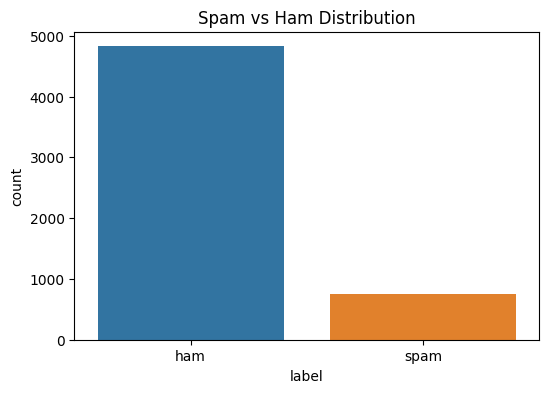


Accuracy: 0.97847533632287

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



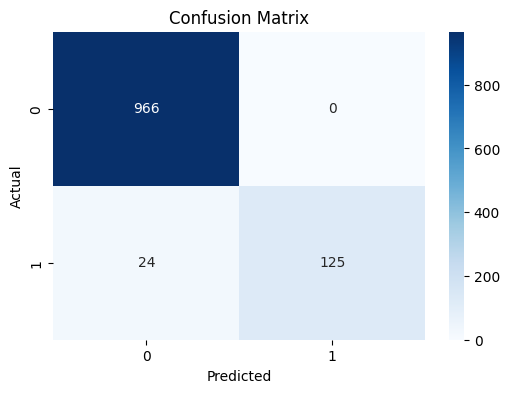

Congratulations! You won a free lottery ticket => Ham
Hey, are we meeting today? => Ham
Urgent! Click here to claim your prize => Spam


In [ ]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================
# STEP 2: LOAD DATA
# =========================

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=['label', 'message'])


# =========================
# STEP 3: EDA (EXPLORATION)
# =========================

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())

# Visualization of class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label')
plt.title("Spam vs Ham Distribution")
plt.show()


# =========================
# STEP 4: PREPROCESSING
# =========================

# Convert labels (spam/ham → 1/0)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Split features and target
X = df['message']
y = df['label']


# =========================
# STEP 5: TRAIN-TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================
# STEP 6: TEXT VECTORIZATION (TF-IDF)
# =========================

vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


# =========================
# STEP 7: MODEL TRAINING
# =========================

model = MultinomialNB()
model.fit(X_train_vec, y_train)


# =========================
# STEP 8: PREDICTION
# =========================

y_pred = model.predict(X_test_vec)


# =========================
# STEP 9: EVALUATION
# =========================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# =========================
# STEP 10: REAL-TIME PREDICTION FUNCTION
# =========================

def predict_message(msg):
    msg_vec = vectorizer.transform([msg])
    pred = model.predict(msg_vec)[0]
    return "Spam" if pred == 1 else "Ham"


# =========================
# STEP 11: TEST EXAMPLES
# =========================

samples = [
    "Congratulations! You won a free lottery ticket",
    "Hey, are we meeting today?",
    "Urgent! Click here to claim your prize"
]

for msg in samples:
    print(msg, "=>", predict_message(msg))